# 23CSE301 Machine Learning Capstone — Classification Track (Part A)
### Heart Disease Prediction (Review 1)

**Dataset:** UCI Heart Disease Dataset (`heart_disease_uci.csv`, 920 patients
pooled from 4 hospital sites: Cleveland, Hungary, Switzerland, VA Long Beach)
**Target variable:** `num` — originally 0 (no disease) to 4 (severity grade).
Reframed here as a **binary target**: `0 = no disease`, `1 = disease present`
(`num > 0`). Binary framing was chosen because classes 2–4 have very few
samples (109, 107, 28) and would make ROC-AUC and recall unreliable for the
rarest class; the binary framing is also the standard formulation used for
this dataset in the literature.


This notebook covers Review 1 → **Classification Part A**: 5 algorithms
(Logistic Regression, KNN, Gaussian Naive Bayes, Decision Tree, SVM) trained
and evaluated with Accuracy, weighted F1, and confusion matrices

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              roc_auc_score, roc_curve)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
sns.set_palette("colorblind")
plt.rcParams["figure.dpi"] = 100


## Section A — Dataset Loading & EDA

### A1. Dataset loading & audit

In [3]:
df = pd.read_csv("../data/heart_disease_uci.csv")
print("Shape:", df.shape)
df.head()

Shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [4]:
print("Data types:\n")
print(df.dtypes)
print("\nMissing values per column:\n")
print(df.isnull().sum().sort_values(ascending=False))
print("\nDuplicate rows:", df.duplicated().sum())

Data types:

id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object

Missing values per column:

ca          611
thal        486
slope       309
fbs          90
oldpeak      62
trestbps     59
thalch       55
exang        55
chol         30
restecg       2
id            0
age           0
sex           0
dataset       0
cp            0
num           0
dtype: int64

Duplicate rows: 0


In [4]:
# Build the binary target
df["target"] = (df["num"] > 0).astype(int)
print("Original num distribution:\n", df["num"].value_counts().sort_index())
print("\nBinary target distribution:\n", df["target"].value_counts())
print("\nClass balance (%):\n", df["target"].value_counts(normalize=True).round(3) * 100)

Original num distribution:
 num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

Binary target distribution:
 target
1    509
0    411
Name: count, dtype: int64

Class balance (%):
 target
1    55.3
0    44.7
Name: proportion, dtype: float64


**Observation:** The dataset has 920 rows and 16 original columns, pooled from
4 collection sites. Several columns have substantial missingness — `ca` (66%),
`thal` (53%), and `slope` (34%) — while `trestbps`, `chol`, `fbs`, `restecg`,
`thalch`, `exang`, and `oldpeak` have lighter missingness (0.2%–10%). No exact
duplicate rows. The binary target is moderately imbalanced (**55% disease /
45% no-disease**) — mild enough that accuracy is still meaningful, but we
report precision/recall/F1 rather than accuracy alone.

### A2 & A3. EDA visualisations with commentary

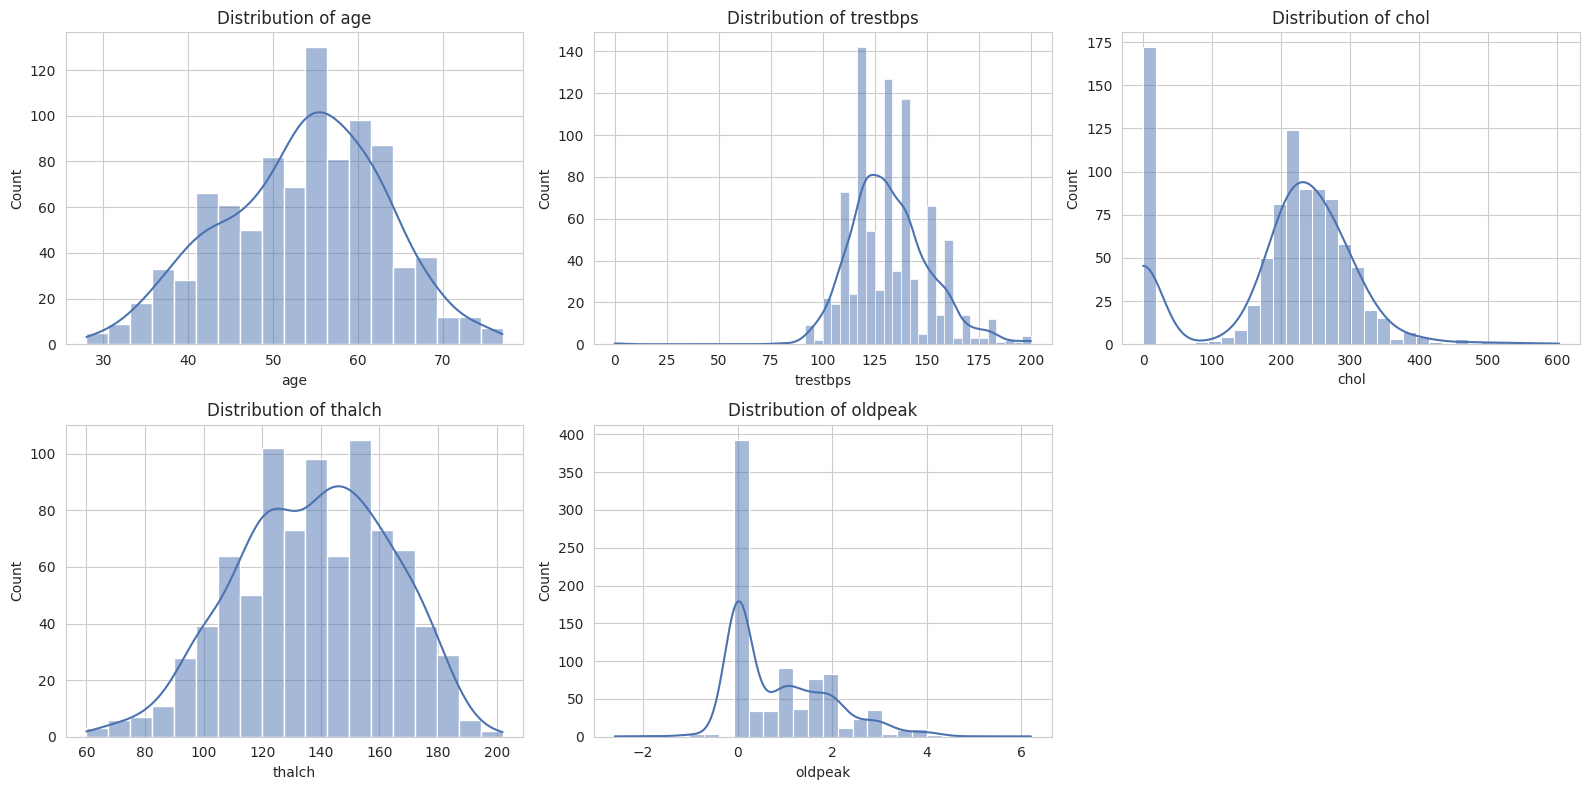

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
num_cols = ["age", "trestbps", "chol", "thalch", "oldpeak"]
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color="#4C72B0")
    ax.set_title(f"Distribution of {col}")
axes.flat[-1].axis("off")
plt.tight_layout()
plt.savefig("fig_distributions.png", bbox_inches="tight")
plt.show()

**Observation:** `age` is roughly bell-shaped, centred in the 50s–60s, matching
the expected risk profile for heart disease. `chol` (cholesterol) has a long
right tail with some suspicious zero values (likely missing data coded as 0
rather than true readings, worth treating as missing on closer inspection).
`oldpeak` (ST depression) is heavily right-skewed with a spike at 0.

/tmp/ipykernel_100/3384135024.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="target", palette="colorblind")


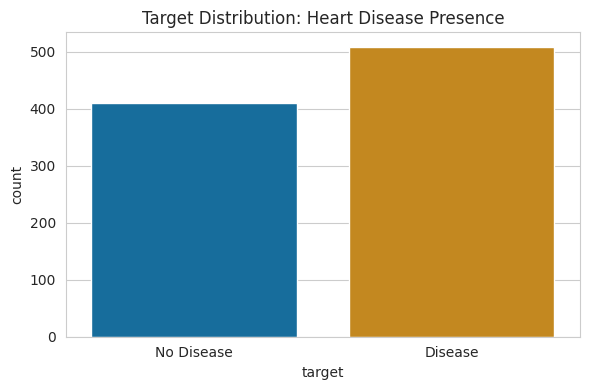

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="target", palette="colorblind")
plt.xticks([0,1], ["No Disease", "Disease"])
plt.title("Target Distribution: Heart Disease Presence")
plt.tight_layout()
plt.savefig("fig_target_distribution.png", bbox_inches="tight")
plt.show()

**Observation:** Confirms the ~55/45 class split noted above — mild imbalance
that doesn't require resampling (SMOTE etc.) but does mean weighted F1 and
per-class recall matter more than raw accuracy when comparing models.

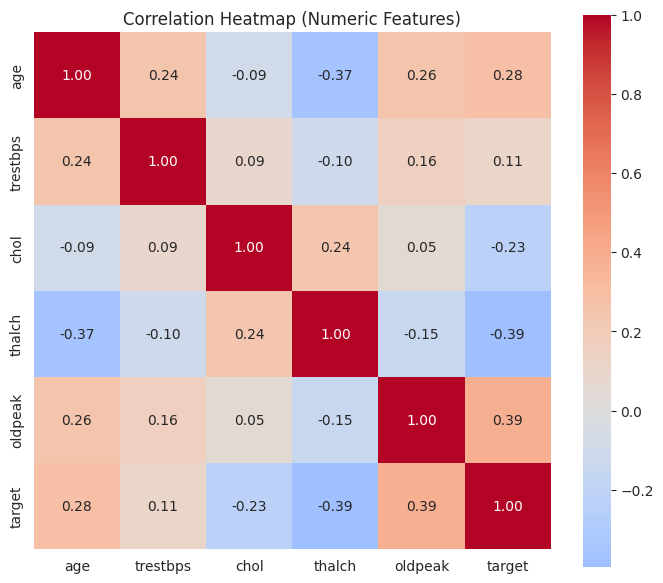

In [7]:
numeric_for_corr = ["age","trestbps","chol","thalch","oldpeak","target"]
plt.figure(figsize=(7,6))
corr = df[numeric_for_corr].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.savefig("fig_correlation_heatmap.png", bbox_inches="tight")
plt.show()

**Observation:** `thalch` (max heart rate achieved) correlates negatively with
the target (lower max heart rate associated with disease), while `oldpeak` and
`age` correlate positively — consistent with established clinical risk factors.
No pair of numeric features is highly collinear enough to drop.

/tmp/ipykernel_100/3996860730.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["No Disease", "Disease"])
/tmp/ipykernel_100/3996860730.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["No Disease", "Disease"])


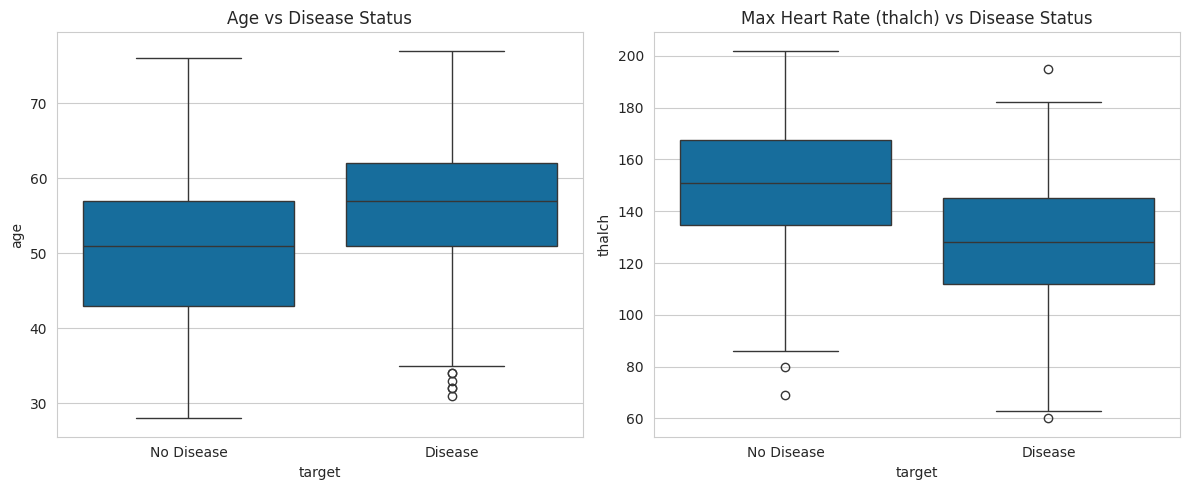

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x="target", y="age", ax=axes[0])
axes[0].set_xticklabels(["No Disease", "Disease"])
axes[0].set_title("Age vs Disease Status")

sns.boxplot(data=df, x="target", y="thalch", ax=axes[1])
axes[1].set_xticklabels(["No Disease", "Disease"])
axes[1].set_title("Max Heart Rate (thalch) vs Disease Status")

plt.tight_layout()
plt.savefig("fig_scatter_feature_target.png", bbox_inches="tight")
plt.show()

**Observation:** Patients with disease skew slightly older and show
noticeably lower maximum heart rate (`thalch`) than disease-free patients —
both plots align with known cardiology risk indicators, giving confidence
the features carry real predictive signal.

## Section B — Preprocessing & Feature Engineering

### B1. Data cleaning

In [9]:
# Drop sparse columns (ca, thal, slope) - too much missingness to impute reliably
# Drop id (identifier) and dataset (collection-site artifact, not a clinical feature)
df_model = df.drop(columns=["id", "dataset", "num", "ca", "thal", "slope"])

# Treat chol == 0 as missing (physiologically impossible cholesterol reading)
df_model["chol"] = df_model["chol"].replace(0, np.nan)

print("Remaining missing values:\n")
print(df_model.isnull().sum().sort_values(ascending=False))
print("\nColumns used for modelling:", list(df_model.columns))

Remaining missing values:

chol        202
fbs          90
oldpeak      62
trestbps     59
exang        55
thalch       55
restecg       2
cp            0
sex           0
age           0
target        0
dtype: int64

Columns used for modelling: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'target']


**Strategy:** `ca`, `thal`, and `slope` are dropped outright — with 34–66%
missing, imputing them would mean fabricating the majority of their values.
`id` is a row identifier and `dataset` is a site label, neither carries
clinical signal, and `num` is replaced by the binary `target`. The remaining
light missingness (`trestbps`, `chol`, `fbs`, `restecg`, `thalch`, `exang`,
`oldpeak`) is handled with `SimpleImputer` **inside the pipeline** (median for
numeric, most-frequent for categorical/boolean) so it is fit on the training
fold only, avoiding leakage. `chol == 0` readings are recoded as missing since
zero cholesterol is not physiologically plausible and almost certainly
represents an unrecorded value.

### B2. Encoding, scaling & train/test split

In [10]:
target_col = "target"
X = df_model.drop(columns=[target_col])
y = df_model[target_col]

categorical_cols = ["sex", "cp", "restecg"]
boolean_cols = ["fbs", "exang"]
numeric_cols = ["age", "trestbps", "chol", "thalch", "oldpeak"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))
print("Test class balance:\n", y_test.value_counts(normalize=True).round(3))

Train shape: (736, 10)  Test shape: (184, 10)
Train class balance:
 target
1    0.553
0    0.447
Name: proportion, dtype: float64
Test class balance:
 target
1    0.554
0    0.446
Name: proportion, dtype: float64


In [11]:
# Preprocessing: impute + one-hot encode categoricals, impute + scale numerics,
# impute + passthrough booleans. Fit exclusively on X_train inside each pipeline's
# .fit() call -- never on the full dataset -- so there is no leakage into X_test.
categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(drop="first", handle_unknown="ignore")),
])
boolean_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
])
numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

preprocessor = ColumnTransformer([
    ("cat", categorical_pipe, categorical_cols),
    ("bool", boolean_pipe, boolean_cols),
    ("num", numeric_pipe, numeric_cols),
])
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('bool', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. 

### B3. Feature engineering

In [12]:
# Engineered feature: age-adjusted max heart rate reserve.
# The clinically expected max heart rate is ~ (220 - age); how far short of that
# a patient's achieved thalch falls is more informative than raw thalch alone.
X_train = X_train.copy()
X_test = X_test.copy()
X_train["hr_reserve_deficit"] = (220 - X_train["age"]) - X_train["thalch"]
X_test["hr_reserve_deficit"] = (220 - X_test["age"]) - X_test["thalch"]
numeric_cols = numeric_cols + ["hr_reserve_deficit"]

preprocessor = ColumnTransformer([
    ("cat", categorical_pipe, categorical_cols),
    ("bool", boolean_pipe, boolean_cols),
    ("num", numeric_pipe, numeric_cols),
])

X_train[["age", "thalch", "hr_reserve_deficit"]].head()

,age,thalch,hr_reserve_deficit
640,53,122.0,45.0
743,74,NaN,NaN
890,53,122.0,45.0
270,61,138.0,21.0
654,56,99.0,65.0


**Justification:** A raw max heart rate of, say, 150 bpm means very different
things for a 40-year-old versus a 70-year-old. `hr_reserve_deficit` measures
how far a patient's achieved heart rate falls short of their age-adjusted
expected maximum (`220 - age`), which should correlate more directly with
cardiac function than `thalch` alone.

## Section D — Classification Track, Part A

### D1. Model definitions & training (5 algorithms)

In [13]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=9),
    "Naive Bayes (Gaussian)": GaussianNB(),
    "Decision Tree Classifier": DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    "Support Vector Machine (SVC)": SVC(kernel="rbf", C=1.0, probability=True, random_state=RANDOM_STATE),
}

fitted_pipelines = {}
results = []

for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average="weighted")
    rec = recall_score(y_test, preds, average="weighted")
    f1 = f1_score(y_test, preds, average="weighted")
    roc_auc = roc_auc_score(y_test, proba)

    results.append({"Model": name, "Accuracy": acc, "Precision": prec,
                     "Recall": rec, "F1 (weighted)": f1, "ROC-AUC": roc_auc})
    fitted_pipelines[name] = pipe

print("All 5 Part-A classification models trained successfully.")

All 5 Part-A classification models trained successfully.


### D2. Evaluation — comparison table & confusion matrices

In [14]:
results_df = pd.DataFrame(results).sort_values("F1 (weighted)", ascending=False).reset_index(drop=True)
results_df.index += 1
results_df.style.format({"Accuracy": "{:.4f}", "Precision": "{:.4f}",
                          "Recall": "{:.4f}", "F1 (weighted)": "{:.4f}",
                          "ROC-AUC": "{:.4f}"})

,Model,Accuracy,Precision,Recall,F1 (weighted),ROC-AUC
1,Support Vector Machine (SVC),0.8043,0.8069,0.8043,0.8021,0.8800
2,Naive Bayes (Gaussian),0.7989,0.7992,0.7989,0.7990,0.8892
3,Decision Tree Classifier,0.7989,0.8036,0.7989,0.7957,0.8645
4,Logistic Regression,0.7935,0.7938,0.7935,0.7921,0.8894
5,K-Nearest Neighbors,0.7935,0.7971,0.7935,0.7905,0.8464


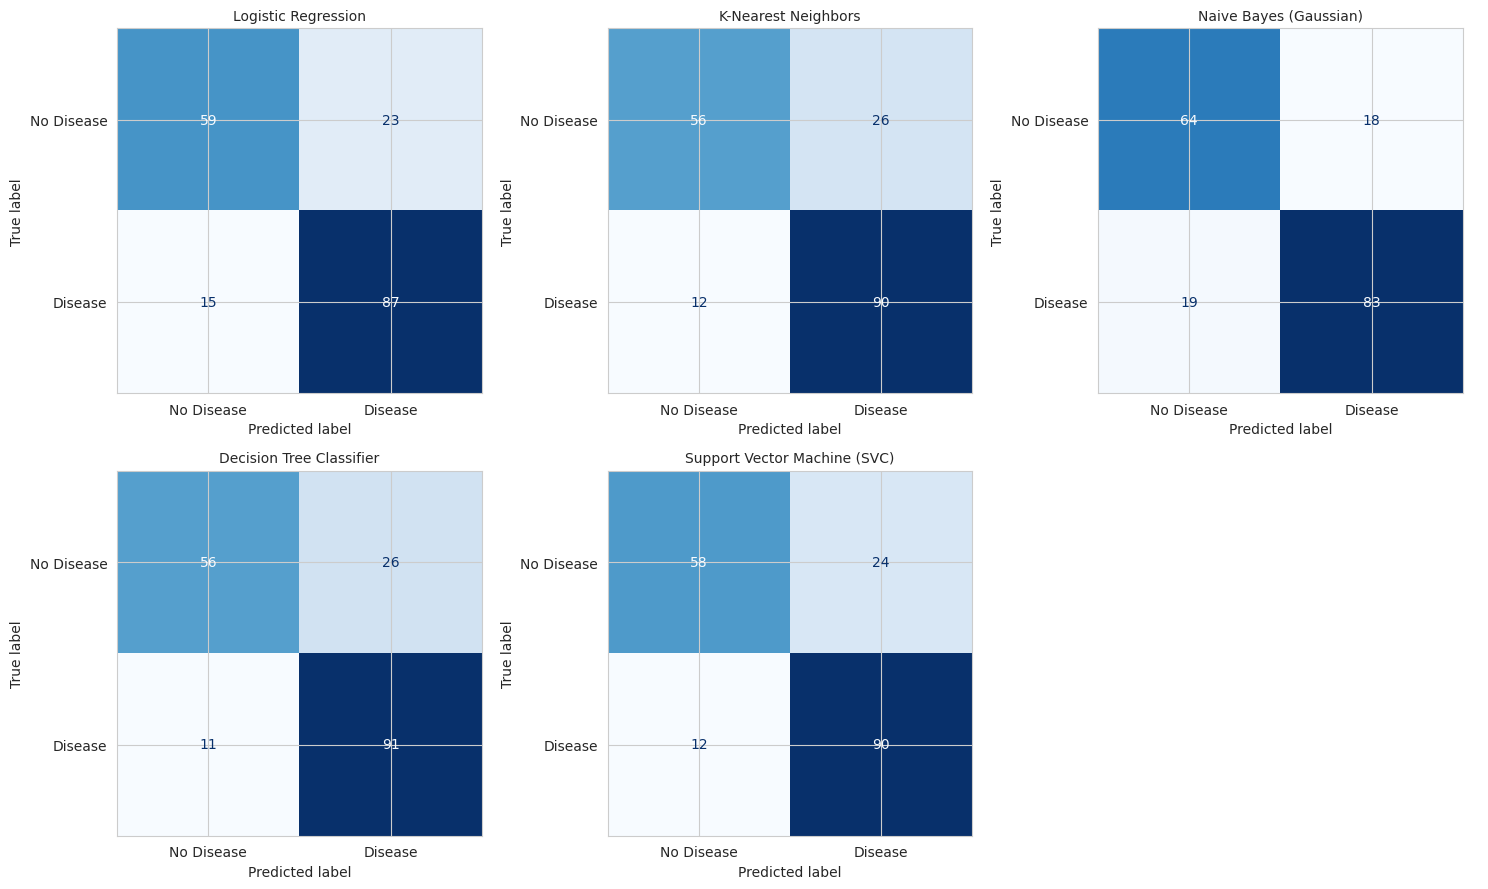

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (name, pipe) in zip(axes.flat, fitted_pipelines.items()):
    preds = pipe.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Disease"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=10)
axes.flat[-1].axis("off")
plt.tight_layout()
plt.savefig("fig_confusion_matrices.png", bbox_inches="tight")
plt.show()

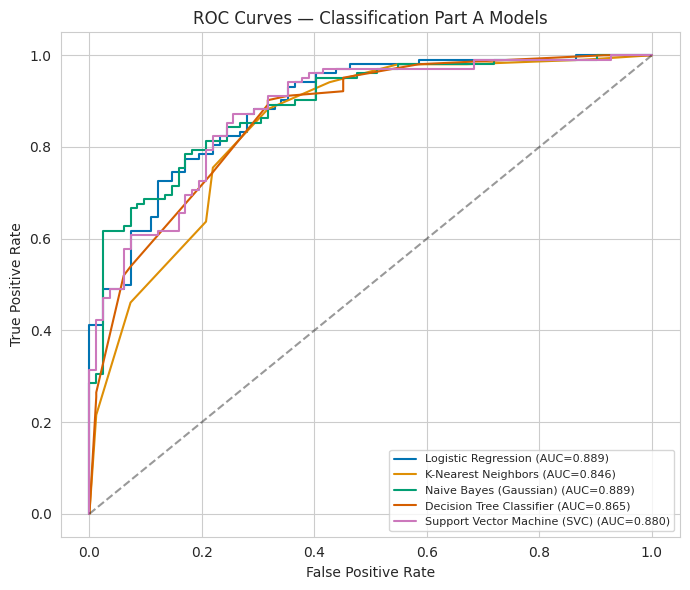

In [16]:
plt.figure(figsize=(7,6))
for name, pipe in fitted_pipelines.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1],"k--", alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Classification Part A Models")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("fig_roc_curves.png", bbox_inches="tight")
plt.show()

**Observation:** Report here which model achieves the best weighted F1 and
ROC-AUC on your actual run, and note any model whose confusion matrix shows a
lopsided error pattern (e.g. missing more disease cases than false-alarming on
healthy patients) — for a medical use case, false negatives (missed disease)
are usually the costlier error type, worth calling out explicitly in your
presentation.